In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("../data/raw/telco_churn.csv")

# Shape of dataset
print("Dataset Shape:", df.shape)

# First five rows
df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Change the data type of total charges from string to int and remove missing values

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].isnull().sum())

11


In [7]:
df[df['TotalCharges'].isnull()][['tenure','MonthlyCharges','TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [8]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print(df['TotalCharges'].isnull().sum()) # 0 because tenure is zero

0


In [9]:
df['customerID'].nunique()

7043

In [10]:
df.drop('customerID', axis=1, inplace=True)

removed customerID because it have no use in prediction

In [11]:
df.duplicated().sum()

np.int64(22)

In [12]:
duplicates = df[df.duplicated()]
duplicates

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
964,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,45.70,45.70,Yes
1338,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes
1491,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
1739,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.90,69.90,Yes
1932,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.20,20.20,No
2713,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.45,20.45,No
2892,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.45,20.45,No
3301,Female,1,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.60,69.60,Yes
3754,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.05,20.05,No
4098,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.20,20.20,Yes


In [13]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

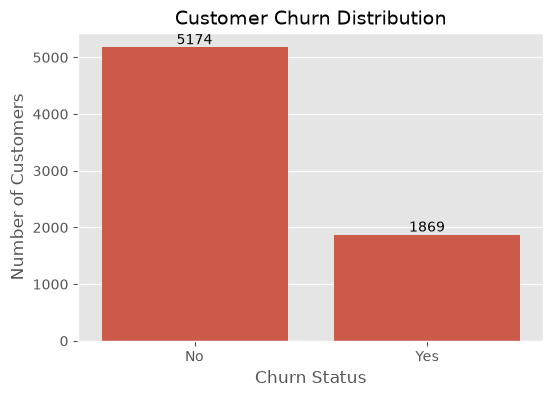

In [15]:
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution", fontsize=14)
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

# Add values on bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [16]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [17]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

# Churn Distribution Analysis

## Observation

- Total customers: **7043**
- Customers who stayed: **5174 (73.46%)**
- Customers who churned: **1869 (26.54%)**

## Business Insight

Approximately one out of every four customers leaves the telecom company.

Although the dataset is moderately imbalanced, the churn rate is high enough to represent a significant business concern.

This justifies building a predictive model to identify customers at risk of churning so that retention strategies can be applied proactively.

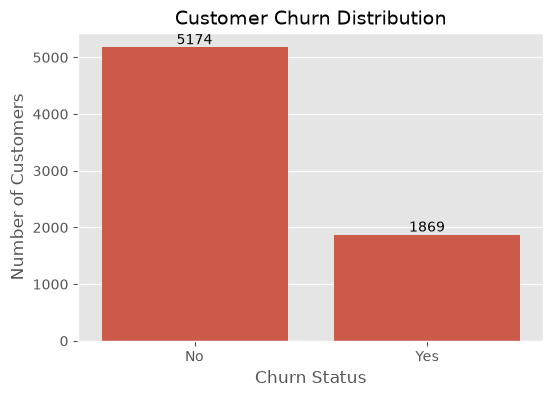

In [18]:
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution", fontsize=14)
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

# Add values on bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

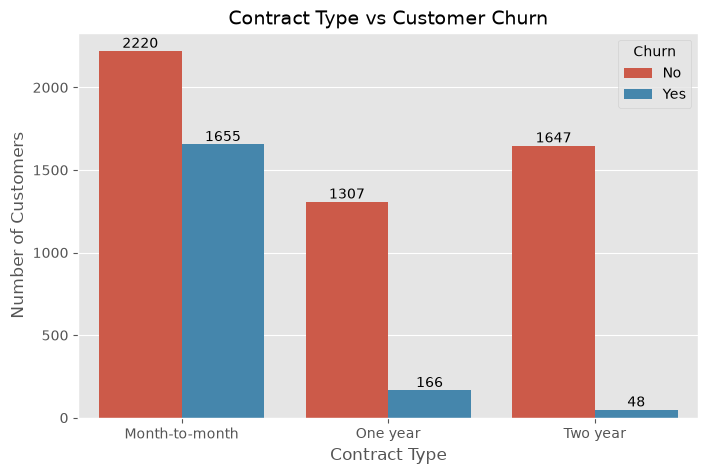

In [19]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Contract Type vs Customer Churn", fontsize=14)
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

## Contract Type vs Churn

### Observation

- Customers with month-to-month contracts have the highest churn.
- Customers with two-year contracts have the lowest churn.

### Business Insight

Customers on flexible monthly contracts are more likely to leave because they are not committed to the company.

The telecom company should encourage these customers to switch to yearly or two-year contracts by offering discounts, loyalty rewards, or personalized retention offers.

### ML Insight

Contract type appears to be a strong predictor of customer churn and is expected to be one of the most influential features during model training.

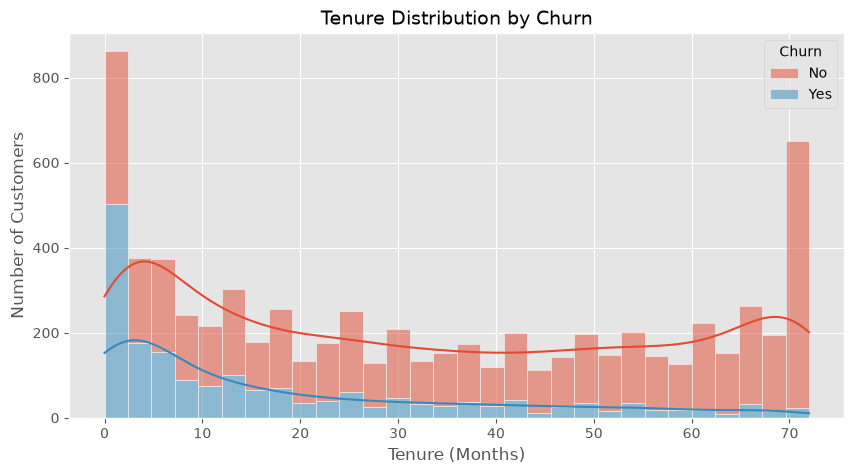

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True,
    multiple="stack"
)

plt.title("Tenure Distribution by Churn", fontsize=14)
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

### Observation

- Customers with lower tenure have a much higher churn rate.
- Customers with higher tenure are more likely to stay with the company.

### Business Insight

New customers are more likely to leave because they have not yet developed loyalty toward the company.

The telecom company should focus its retention efforts during the first few months by providing onboarding support, promotional offers, and loyalty benefits.

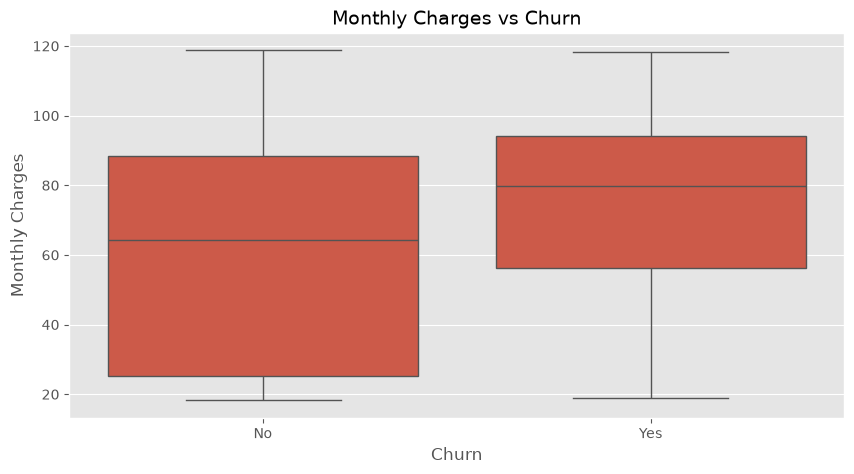

In [21]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn", fontsize=14)
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()



📈 Our EDA Story So Far

Look how the story is building:

Graph 1

📊 27% customers churn

↓

Graph 2

📅 Month-to-month customers churn more

↓

Graph 3

⏳ New customers churn more

↓

Graph 4

💰 Customers with higher monthly charges churn more

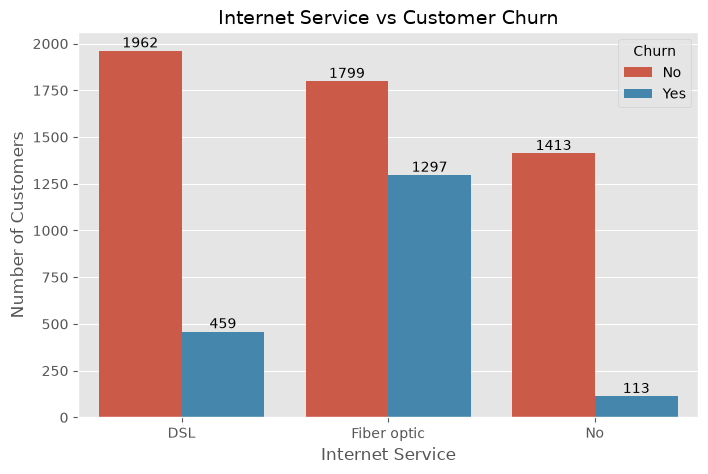

In [22]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Internet Service vs Customer Churn", fontsize=14)
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

## Internet Service vs Churn

### Observation

- Customers using Fiber Optic internet have the highest churn rate.
- Customers without internet service have the lowest churn.

### Business Insight

Fiber Optic customers are likely paying higher monthly charges and therefore may have higher expectations regarding service quality. The company should focus on retaining high-value Fiber Optic customers through personalized offers, loyalty rewards, and premium customer support.

### ML Insight

InternetService appears to be an important feature for churn prediction because different service types show noticeably different churn behavior.

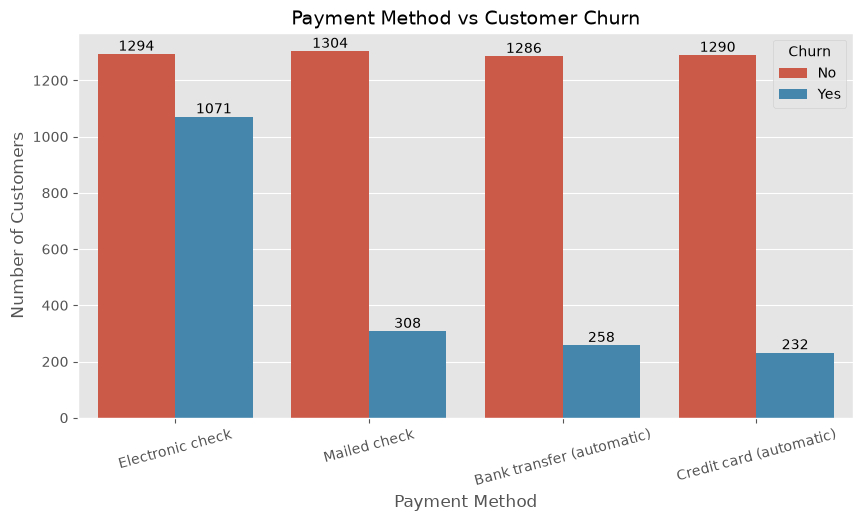

In [23]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Payment Method vs Customer Churn", fontsize=14)
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [24]:
#nominal encoding
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

In [25]:
#one hot encoding
categorical_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 
                     'OnlineBackup', 'DeviceProtection', 'TechSupport',
                     'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [26]:
print(df.shape)
df.head()

(7043, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [27]:
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

In [28]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


In [29]:
from sklearn.preprocessing import StandardScaler
import joblib

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

joblib.dump(scaler, '../models/scaler.pkl')

['../models/scaler.pkl']

In [30]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.277445,0,1,-1.160323,-0.992611,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0.066327,1,0,-0.259629,-0.172165,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,-1.236724,1,1,-0.362660,-0.958066,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0.514251,0,0,-0.746535,-0.193672,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,-1.236724,1,1,0.197365,-0.938874,1,...,0,0,0,0,0,0,0,0,1,0


In [31]:
df.dtypes.value_counts()
df[numeric_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7.043000e+03,7.043000e+03,7.043000e+03
mean,-2.421273e-17,-6.406285e-17,-3.783239e-17
std,1.000071e+00,1.000071e+00,1.000071e+00
min,-1.318165e+00,-1.545860e+00,-1.005780e+00
25%,-9.516817e-01,-9.725399e-01,-8.299464e-01
50%,-1.372744e-01,1.857327e-01,-3.905282e-01
75%,9.214551e-01,8.338335e-01,6.648034e-01
max,1.613701e+00,1.794352e+00,2.825806e+00


In [32]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(5634, 30) (1409, 30)


In [33]:
print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (5634, 30)
Testing : (1409, 30)


# Train-Test Split

## Objective

The dataset was divided into training and testing sets.

- Training Set: 80%
- Testing Set: 20%

`stratify=y` was used to preserve the original churn distribution in both datasets.

`random_state=42` was used to ensure reproducible results.

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Class imbalance ratio — needed for XGBoost later
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

results = []

def evaluate_model(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_proba)
    }
    results.append(metrics)
    print(f"===== {name} =====")
    for k, v in metrics.items():
        if k != "Model":
            print(f"{k}: {v:.4f}")
    return model

scale_pos_weight: 2.768561872909699


In [35]:
lr_model = evaluate_model("Logistic Regression", LogisticRegression(max_iter=1000, random_state=42))

===== Logistic Regression =====
Accuracy: 0.8062
Precision: 0.6593
Recall: 0.5588
F1: 0.6049
ROC_AUC: 0.8422


In [36]:
dt_model = evaluate_model("Decision Tree", DecisionTreeClassifier(max_depth=6, random_state=42))

===== Decision Tree =====
Accuracy: 0.8006
Precision: 0.6667
Recall: 0.4973
F1: 0.5697
ROC_AUC: 0.8219


In [37]:
rf_model = evaluate_model("Random Forest", RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42))

===== Random Forest =====
Accuracy: 0.8006
Precision: 0.6703
Recall: 0.4893
F1: 0.5657
ROC_AUC: 0.8445


In [38]:
xgb_default = evaluate_model("XGBoost (Default)", XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    eval_metric='logloss', random_state=42,
    scale_pos_weight=scale_pos_weight
))

===== XGBoost (Default) =====
Accuracy: 0.7559
Precision: 0.5282
Recall: 0.7513
F1: 0.6203
ROC_AUC: 0.8312


In [39]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
print("Best params:", random_search.best_params_)

best_xgb = random_search.best_estimator_
evaluate_model("XGBoost (Tuned)", best_xgb)

Best params: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
===== XGBoost (Tuned) =====
Accuracy: 0.7516
Precision: 0.5208
Recall: 0.8048
F1: 0.6324
ROC_AUC: 0.8450


,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [40]:
results_df = pd.DataFrame(results).sort_values(by="ROC_AUC", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
4,XGBoost (Tuned),0.751597,0.520761,0.804813,0.632353,0.844971
2,Random Forest,0.800568,0.670330,0.489305,0.565688,0.844457
0,Logistic Regression,0.806246,0.659306,0.558824,0.604920,0.842179
3,XGBoost (Default),0.755855,0.528195,0.751337,0.620309,0.831192
1,Decision Tree,0.800568,0.666667,0.497326,0.569678,0.821901


In [41]:
import shap
print(shap.__version__)

C:\Users\smile\OneDrive\Desktop\TeleGuard AI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


0.52.0


Positive values push towards Churn.

Negative values push towards No Churn.

In [44]:
import shap

# Create SHAP explainer for the tuned XGBoost model
explainer = shap.TreeExplainer(best_xgb)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

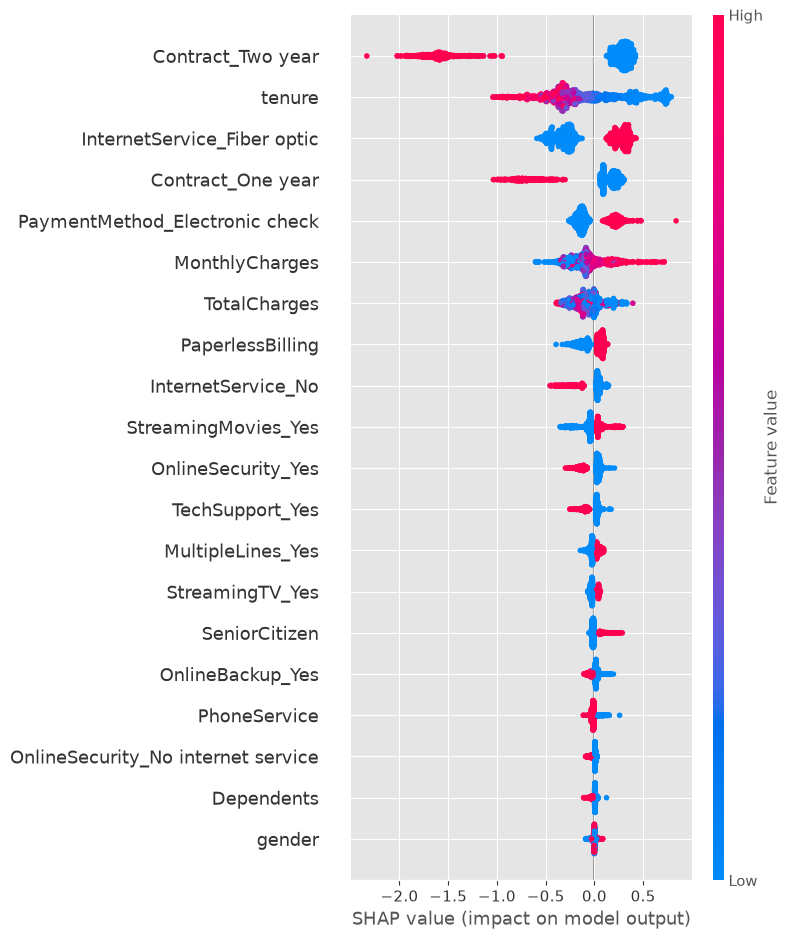

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()
plt.show()

### SHAP Summary Plot Interpretation

High-> red low -> blue
➡️ pushes the prediction towards Churn
⬅️ pushes the prediction towards No Churn

The SHAP Summary Plot explains how different features influence the churn prediction.

Key observations:

- Customers with **Two-year contracts** have the lowest churn risk.
- Customers with **low tenure** are more likely to churn.
- Customers with **Fiber Optic Internet** show higher churn probability.
- Higher **Monthly Charges** increase churn risk.
- Customers using **Electronic Check** are more likely to churn.


# SHAP Feature Importance (Bar Plot)

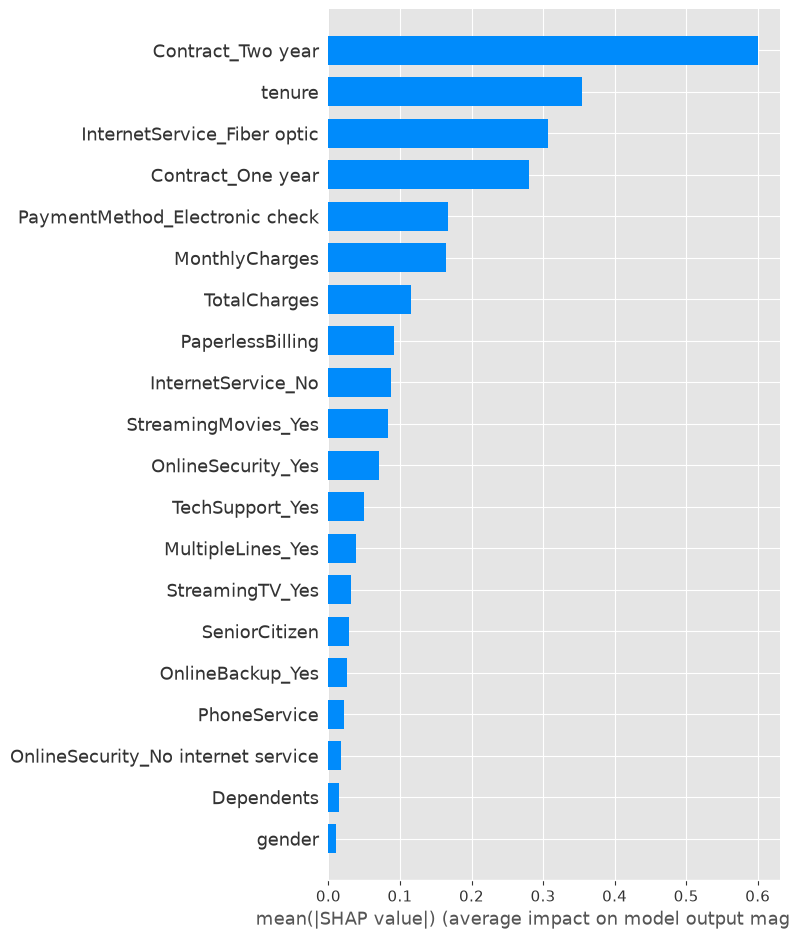

In [47]:
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.show()

### Interpretation

The SHAP Feature Importance plot ranks features according to their overall contribution to the churn prediction model.

Key observations:

- Contract type is the strongest predictor of customer churn.
- Customer tenure is the second most important feature.
- Fiber Optic Internet, Electronic Check payment method, and Monthly Charges also have significant influence.

These findings are consistent with the insights obtained during Exploratory Data Analysis (EDA), demonstrating that the model has learned meaningful business relationships.

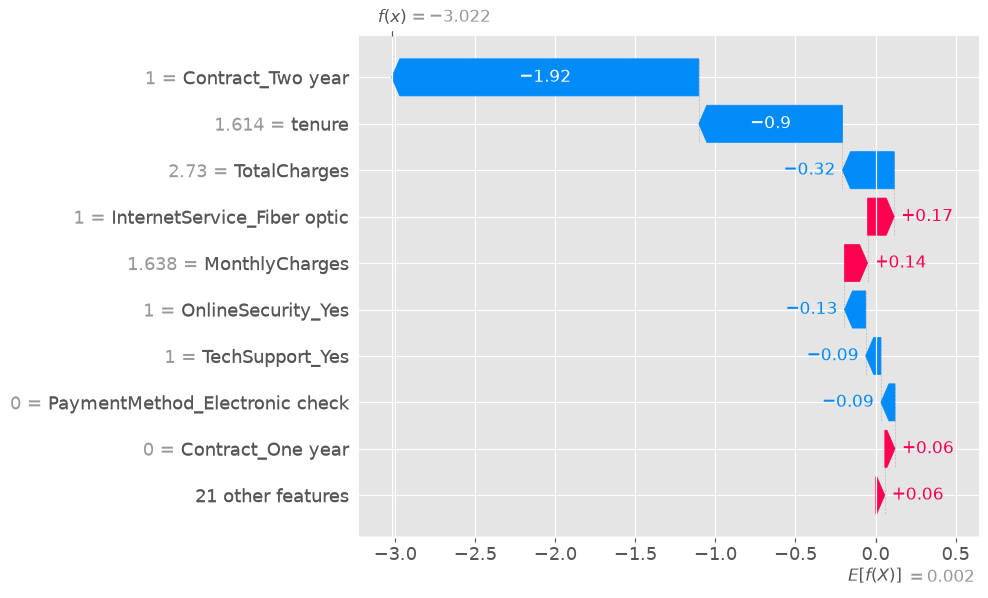

In [49]:
sample = X_test.iloc[[0]]

explanation = explainer(sample)

shap.plots.waterfall(explanation[0], max_display=10)

### SHAP Waterfall Plot Interpretation

The SHAP Waterfall Plot explains the prediction for an individual customer.

For this customer:

- A Two-Year Contract was the strongest factor reducing churn.
- Long customer tenure significantly increased retention.
- High Total Charges also contributed toward lower churn probability.
- Fiber Optic Internet and higher Monthly Charges slightly increased churn risk.
- Overall, the positive retention factors outweighed the risk factors, resulting in a low churn prediction.

This visualization improves model transparency by clearly showing how each feature contributed to the final prediction.

In [50]:
type(best_xgb)

type(scaler)

X.columns[:5]

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure'], dtype='str')

In [51]:
import os
import json
import joblib

# Create models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save trained XGBoost model
joblib.dump(best_xgb, "../models/churn_model.pkl")

# Save StandardScaler
joblib.dump(scaler, "../models/scaler.pkl")

# Save feature names (important for inference)
with open("../models/feature_columns.json", "w") as f:
    json.dump(list(X.columns), f, indent=4)

print("✅ Model saved.")
print("✅ Scaler saved.")
print("✅ Feature names saved.")

✅ Model saved.
✅ Scaler saved.
✅ Feature names saved.


In [1]:
import pandas as pd
df = pd.read_csv('../data/raw/telco_churn.csv')
df.drop(columns=['customerID', 'Churn']).head(30).to_csv('../data/processed/test_batch.csv', index=False)